## 실습 문제 1: 3차 함수에 노이즈 추가 및 시각화

3차 함수 f(x) = x^3 - x^2 +3 를 생성하고, 여기에 무작위 노이즈를 추가하여 데이터를 만듭니다. 이후 Matplotlib을 사용하여 원본 함수와 노이즈가 추가된 데이터를 시각화합니다. 이는 데이터에 노이즈를 추가함으로써 모델의 일반화 성능을 향상시키는 효과를 이해하는 데 목적이 있습니다.

- **요구사항**:
    1. x 의 범위를 -5에서 5까지 100개의 점으로 생성하세요.
    2. 3차 함수 y=x^3 - x^2 +3 를 계산하세요.
    3. y 에 평균 0, 표준편차 10의 정규 분포 노이즈를 추가하여 증강된 데이터를 생성하세요. (np.random.normal)
    4. Matplotlib을 사용해 원본 함수를 선으로, 노이즈가 추가된 데이터를 산점도로 시각화하세요. (plt.plot, plt.scatter)


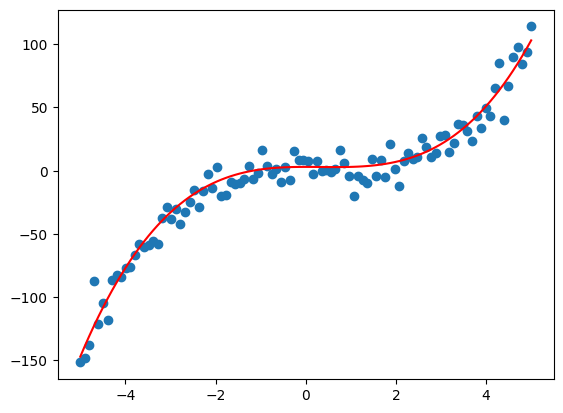

In [74]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**3 - x**2 + 3

x = np.linspace(-5,5,100)
plt.plot(x, f(x), color='red')
plt.scatter(x, f(x)+np.random.normal(0,10,100))
plt.show()

## 실습 문제 2: 소프트맥스 함수 (Softmax Function)

여러분은 이미지를 받아서 강아지인지 고양이인지 분류하는 간단한 인공지능 모델을 만들고 있다고 가정해 봅시다. 이 모델은 내부적으로 이미지에 대한 '강아지 점수($z_{dog}$)'와 '고양이 점수($z_{cat}$)'를 계산합니다. 점수가 높을수록 모델은 해당 클래스일 가능성이 높다고 판단합니다.

소프트맥스(Softmax) 함수는 이 '점수'들을 각 클래스(강아지, 고양이)에 대한 '확률'로 변환하는 중요한 역할을 합니다. 예를 들어, [강아지 점수=3, 고양이 점수=1] 이라면, 소프트맥스는 이를 [강아지일 확률=0.88, 고양이일 확률=0.12] 와 같이 변환하여 두 확률의 합이 1이 되도록 합니다.


**요구사항:**

1.  **입력 설정:**
    * '강아지 점수 ($z_{dog}$)'는 $-5$부터 $5$까지 $100$개의 구간으로 변화시킵니다.
    * '고양이 점수 ($z_{cat}$)'는 $1$로 고정합니다.
2.  **소프트맥스 계산:** NumPy를 사용하여 $z = [z_{dog}, z_{cat}]$ 에 대한 소프트맥스 확률 값을 계산합니다.

$$ \text{softmax}(z)_{i} = \frac{e^{z_i}}{\sum_{j} e^{z_j}} $$

여기서:

* 분자 $e^{z_i}$​는 클래스 i의 점수(z)에 지수 함수를 적용한 값입니다. i는 클래스 인덱스(dog=0, cat=1)를 나타냅니다

* 분모 $\sum_{j} e^{z_j}$​는 모든 클래스(dog와 cat)의 점수(z) 에 대한 지수 함수값의 합계입니다.

(0.0, 1.0)

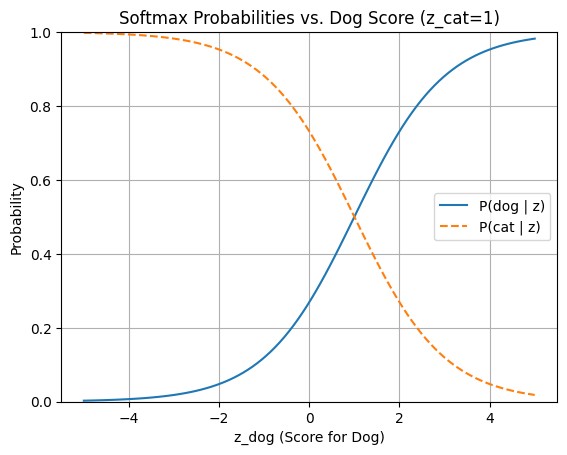

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    z = np.exp(x)
    return z / np.sum(z, axis=1, keepdims=True) # (100, 2) 차원을 유지하도록 keepdims를 사용

z_dog = np.linspace(-5, 5, 100)
z_cat =  np.ones_like(z_dog)
z = np.column_stack((z_dog, z_cat))

prob = softmax(z)
prob_dog, prob_cat = prob[:, 0], prob[:, 1]

plt.plot(z_dog, prob_dog, label='P(dog | z)')
plt.plot(z_dog, prob_cat, label='P(cat | z)', ls='--')
plt.xlabel('z_dog (Score for Dog)')
plt.ylabel('Probability')
plt.title('Softmax Probabilities vs. Dog Score (z_cat=1)')
plt.grid()
plt.legend()
plt.ylim(0, 1)

## 실습 문제 3: 드롭아웃

드롭아웃은 신경망 학습 시 과적합을 방지하기 위해 일부 뉴런을 무작위로 비활성화(0) 하는 기법입니다. 이 문제에서는 드롭아웃 마스크를 생성하여 가중치에 적용하고, 원본 가중치와 드롭아웃이 적용된 가중치에 특정 숫자를 곱하여 스케일링을 시뮬레이션합니다.

- **요구사항**:
    1. 5x5 크기의 가중치 w 를 np.random.randn(5, 5)로 생성하세요.
    2. dropout 함수를 정의하고, 드롭아웃 확률을 0.5로 설정하고, np.random.rand(5, 5)를 사용해 0과 1 사이의 난수를 생성하세요.
    3. 난수가 0.5 이상이면 1(활성화), 미만이면 0(비활성화)인 마스크를 만드세요.
    4. 원본 가중치와 드롭아웃이 적용된 가중치(가중치 * 마스크)를 계산하여 반환하세요.
    5. 원본 가중치와 드롭아웃이 적용된 가중치에 2를 곱한 결과를 출력하세요.

In [86]:
def dropout(w, prob=0.5):
  mask = np.random.rand(*w.shape) > prob
  return w*mask

w = np.random.randn(5,5)
dropout(w)

array([[-0.0752002 , -2.23751656, -0.88061245,  0.        ,  0.        ],
       [ 0.        ,  0.86710396, -0.68635814,  0.        , -0.09358239],
       [-0.41972139, -0.        ,  0.        , -0.        , -0.55479313],
       [ 0.        , -0.        ,  0.65369931,  0.        , -0.73178814],
       [-0.60701641,  0.        ,  0.        , -1.87589996, -0.73795803]])

## 실습 문제 4: 간단한 신경망

SimpleNeuralNetwork 에 필요한 계층 클래스들(Dense, ReLU, Softmax)을 구현하세요. 이 신경망은 입력 값을 받아 순전파(forward propagation)만 수행하는 간단한 구조를 가집니다. 각 계층은 독립적인 클래스로 구현하고, 이들을 조합하여 전체 신경망을 만들어야 합니다.

## 구현할 클래스들:

### 1. Dense 클래스
**Methods:**
- __init__(input_size: int, output_size: int): 입력 크기와 출력 크기를 받아 가중치(weights)와 편향(bias)을 초기화합니다. 가중치는 He 방법으로 초기화하고, 편향은 0으로 초기화합니다.
- forward(inputs: np.ndarray) -> np.ndarray: 입력 데이터에 대해 선형 변환(inputs @ weights + bias)을 수행하고 결과를 반환합니다.

### 2. ReLU 클래스
**Methods:**
- __init__(): 초기화 메서드입니다. 필요한 경우 내부 상태를 설정합니다.
- forward(inputs: np.ndarray) -> np.ndarray: 입력 데이터에 ReLU 활성화 함수를 적용하고 결과를 반환합니다. (np.maximum 활용)

### 3. Softmax 클래스
**Methods:**
- __init__(): 초기화 메서드입니다. 필요한 경우 내부 상태를 설정합니다.
- forward(inputs: np.ndarray) -> np.ndarray: 입력 데이터에 Softmax 함수를 적용하여 각 클래스에 대한 확률 분포를 반환합니다.

## 요구사항:
1. NumPy 라이브러리를 사용하여 모든 계산을 수행합니다.
2. 계층 클래스들은 각각 독립적으로 동작해야 하며, 다른 계층과의 인터페이스는 forward 메서드로 통일합니다.

In [87]:
class Dense:
    def __init__(self, input_size, output_size, init='he'):
        self.weights = np.random.normal(0, np.sqrt(2/input_size), (input_size, output_size))

    def forward(self, inputs):
        return inputs @ self.weights # inputs는 개수

class ReLU:
    def __init__(self):
        pass

    def forward(self, inputs):
        return np.maximum(inputs, 0) # 0보다 작으면 0 리턴, 0보다 크면 inputs 그대로 출력

class Softmax:
    def __init__(self):
        pass

    def forward(self, inputs):
        z = np.exp(inputs)
        return z / np.sum(z, axis=1, keepdims=True)

class SimpleNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        self.dense1 = Dense(input_size, hidden_size)
        self.relu = ReLU()
        self.dense2 = Dense(hidden_size, output_size)
        self.softmax = Softmax()

    def forward(self, inputs):
        x = self.dense1.forward(inputs)
        x = self.relu.forward(x)
        x = self.dense2.forward(x)
        x = self.softmax.forward(x)
        return x

In [88]:
np.random.seed(0)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

network = SimpleNeuralNetwork(2, 4, 2)
prob = network.forward(X)

print("입력:", X)
print("\n출력 확률:", prob)
print("\n확률 합:", np.sum(prob, axis=1))

입력: [[0 0]
 [0 1]
 [1 0]
 [1 1]]

출력 확률: [[0.5        0.5       ]
 [0.43807079 0.56192921]
 [0.40261726 0.59738274]
 [0.42932017 0.57067983]]

확률 합: [1. 1. 1. 1.]
